Nama Mahasiswa :
1. Alif Januar Rizky       (23051130015)
2. Nicosius Aldho Wiratama (23051130017)
3. Anas Ridwhanul Dahlan   (23051130050)

### **California Housing**

### **Contents**

1. Business Problem
2. Data Understanding
3. Preprocessing (Data Cleaning, Feature Selection & Feature Engineering)
4. Modeling
5. Analytics (Algorithm + Metrics)
6. Conclusion
7. rekomendation

### **Bussiness Problem Understanding**

**Context**

California merupakan salah satu wilayah dengan pertumbuhan ekonomi paling dinamis di Amerika Serikat, ditandai dengan tingginya mobilitas penduduk, perkembangan industri, serta perbedaan tingkat penghasilan antarwilayah yang cukup signifikan. Variasi pendapatan masyarakat di berbagai kota dan distrik di California berdampak besar terhadap sejumlah aspek strategis, seperti harga properti, kualitas fasilitas umum, tingkat pendidikan, hingga potensi investasi.

Dataset California Housing menyediakan informasi demografis dan karakteristik lingkungan yang mencerminkan kondisi sosial-ekonomi suatu wilayah, seperti jumlah penduduk, usia median bangunan, jumlah rumah tangga, total kamar, hingga kedekatan lokasi dengan laut (ocean proximity). Salah satu variabel terpenting dalam dataset ini adalah Median Income, yang menjadi indikator fundamental dalam memahami daya beli dan kesejahteraan masyarakat pada suatu area.

Memahami serta memprediksi nilai Median Income dapat membantu berbagai pihak, seperti pemerintah, perusahaan real estate, institusi keuangan, dan peneliti dalam membuat keputusan berbasis data yang lebih akurat.

**Problem Statement**

Dalam perencanaan pembangunan wilayah dan analisis ekonomi lokal, informasi mengenai distribusi pendapatan sangat dibutuhkan. Namun, pengumpulan data pendapatan seringkali memakan biaya besar, memerlukan survei langsung, dan tidak dapat dilakukan pada skala luas secara cepat.

Oleh karena itu, muncul pertanyaan utama:

- Apakah mungkin membangun model machine learning yang mampu memprediksi Median Income berdasarkan variabel demografis dan geografis yang tersedia?

Dengan kata lain, apakah fitur-fitur dalam dataset seperti total kamar, jumlah penduduk, jumlah rumah tangga, usia rumah, hingga faktor geografis bisa digunakan untuk menghasilkan estimasi pendapatan yang akurat?

**Goals**

Tujuan dari proyek ini adalah:

1. Membangun model prediksi MedianIncome menggunakan teknik machine learning berbasis regresi.
2. Mengidentifikasi fitur apa saja yang paling memengaruhi prediksi pendapatan.
3. Menghasilkan model terbaik yang dapat memberikan estimasi akurat untuk keperluan analisis ekonomi dan perencanaan wilayah.
4. Menyediakan insight berbasis data mengenai hubungan antara kondisi lingkungan dan tingkat pendapatan masyarakat.

**Analytic Approach**

Pendekatan analitik yang digunakan meliputi beberapa tahapan utama:

1. Data Understanding
Melakukan eksplorasi data (EDA), memahami distribusi variabel, korelasi antar fitur, serta mempelajari potensi pola awal dalam data.
2. Data Preprocessing
Meliputi penanganan missing value, outlier, encoding variabel kategorikal, scaling fitur numerik, dan pembagian data menjadi train-test split.
3. Modeling
Mengembangkan beberapa model regresi seperti Linear Regression dan Random Forest untuk memprediksi Median Income.
4. Model Evaluation & Analytics
Menilai performa model menggunakan metrik regresi dan melakukan interpretasi terhadap perilaku model melalui feature importance, residual analysis, dan komparasi model.

Dengan pendekatan tersebut, proyek ini diharapkan dapat menghasilkan model prediksi yang robust, terukur, dan memberikan insight interpretatif.

### **Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

import warnings
warnings.filterwarnings('ignore')

**load Dataset**

In [2]:
df = pd.read_csv('data_california_house.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
5,-117.79,33.80,11.0,10535.0,1620.0,4409.0,1622.0,6.6700,<1H OCEAN,283200.0
6,-117.80,33.81,14.0,1206.0,142.0,572.0,149.0,8.8470,<1H OCEAN,388700.0
7,-121.26,38.69,17.0,3917.0,638.0,1809.0,564.0,5.2586,INLAND,137000.0
8,-117.65,33.48,6.0,1638.0,188.0,572.0,174.0,13.0502,<1H OCEAN,500001.0
9,-122.27,37.97,10.0,15259.0,2275.0,7266.0,2338.0,6.0666,NEAR BAY,272400.0


Kode diatas digunakan untuk membaca dataset menggunakan pd.read_csv() dan menyimpannya ke variabel df. Setelah itu, df.head(10) menampilkan 10 baris pertama dari tabel agar kita bisa melihat gambaran awal datanya. Dari output terlihat beberapa kolom penting seperti longitude, latitude, total_rooms, population, median_income, hingga ocean_proximity, yang semuanya akan digunakan dalam analisis dan pemodelan.

**Informasi Dasar Dataset**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14311 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   ocean_proximity     14448 non-null  object 
 9   median_house_value  14448 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.1+ MB


Kode df.info() digunakan untuk melihat ringkasan struktur dataset. Dari hasil tersebut kita bisa mengetahui:

- Informasi Utama

    Jumlah data: 14.448 baris

    Jumlah kolom: 10 fitur

    Tipe data dominan: float64 (angka desimal)

    Ada 1 kolom bertipe object, yaitu ocean_proximity (kategori)

- Missing Value

    Kolom total_bedrooms memiliki missing values (tidak penuh)

**Statistik Deskriptif**

In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,14448.000000,14448.000000,14448.000000,14448.000000,14311.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,-119.566647,35.630093,28.618702,2640.132683,538.260709,1425.157323,499.508929,3.866667,206824.624516
std,2.006587,2.140121,12.596694,2191.612441,423.577544,1149.580157,383.098390,1.891158,115365.476182
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1451.000000,295.000000,784.000000,279.000000,2.570600,119600.000000
50%,-118.490000,34.260000,29.000000,2125.000000,435.000000,1165.000000,410.000000,3.539100,180000.000000
75%,-118.000000,37.710000,37.000000,3148.000000,647.000000,1724.000000,604.000000,4.736100,263900.000000
max,-114.310000,41.950000,52.000000,32627.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Dari output tersebut, kita dapat melihat ringkasan statistik seperti jumlah data (count), nilai rata-rata (mean), penyimpangan standar (std), nilai minimum, serta nilai kuartil (25%, 50%, 75%) untuk setiap kolom numerik. Informasi ini penting untuk mengetahui sebaran data, melihat apakah ada nilai ekstrim (outlier), dan memahami karakteristik dasar dari setiap fitur. Misalnya, median_income memiliki nilai antara 0.49 hingga 15, sementara jumlah ruangan (total_rooms) memiliki rentang sangat besar yang menunjukkan potensi outlier.

**Cek Missing Values**

In [5]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        137
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

Output tersebut menunjukkan bahwa hanya kolom total_bedrooms yang memiliki missing values sebanyak 137 baris. Sementara itu, semua kolom lainnya tidak memiliki data yang hilang. Informasi ini penting untuk menentukan langkah preprocessing selanjutnya, karena kolom yang memiliki nilai kosong perlu diperbaiki agar model dapat bekerja dengan baik.


- Semua kolom tidak memiliki missing values, kecuali total_bedrooms.

- Jumlah missing values pada total_bedrooms: 137.


**Distribusi Target median_income**

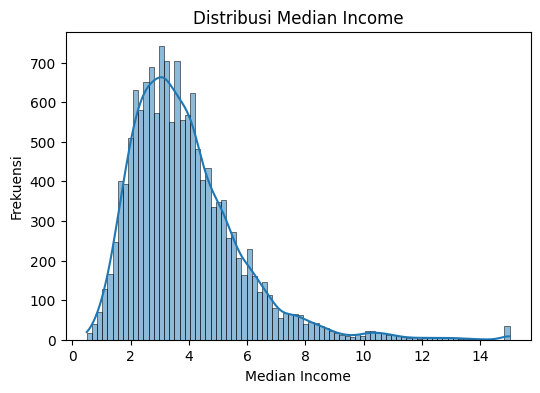

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['median_income'], kde=True)
plt.title("Distribusi Median Income")
plt.xlabel("Median Income")
plt.ylabel("Frekuensi")
plt.show()

Grafik histogram di atas menggambarkan distribusi nilai median_income di wilayah California. Terlihat bahwa sebagian besar nilai pendapatan berada pada rentang 2 hingga 5, dan frekuensinya menurun seiring bertambahnya pendapatan. Bentuk grafik menunjukkan pola right-skewed, artinya masih ada beberapa wilayah dengan pendapatan yang jauh lebih tinggi dibandingkan wilayah lainnya.

- Mayoritas nilai median_income berada di sekitar 2–5.

- Distribusi condong ke kanan (right-skewed), menandakan adanya wilayah berpendapatan tinggi namun jumlahnya sedikit.

**Korelasi antar fitur numerik**

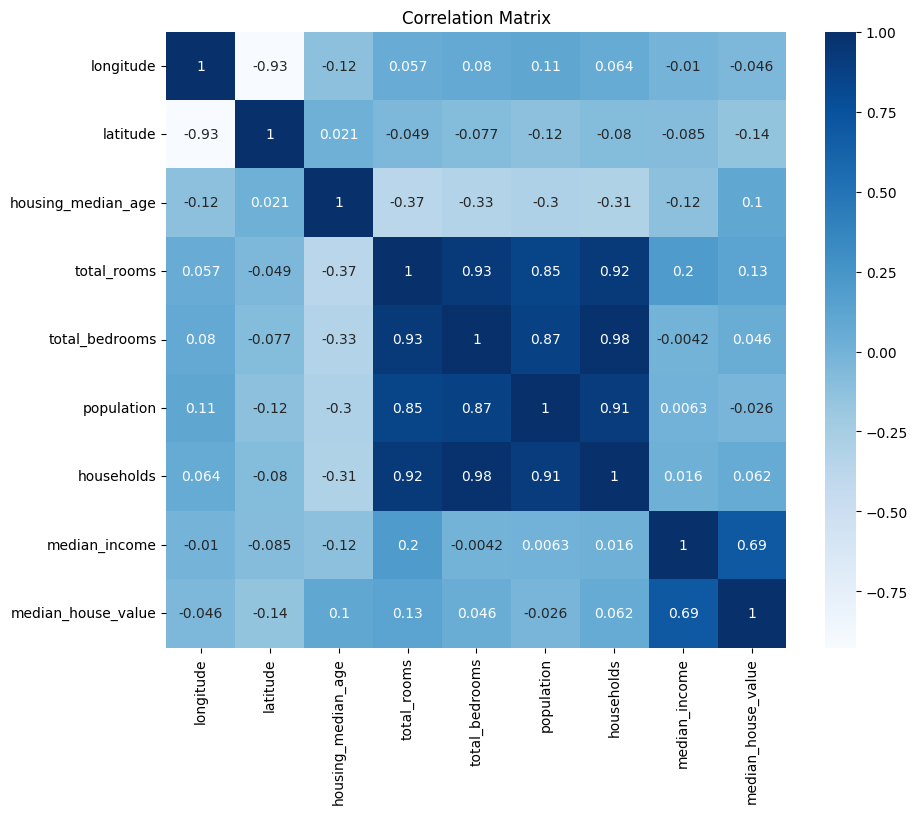

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

Heatmap di atas menunjukkan hubungan antar fitur numerik dalam dataset California Housing. Warna biru gelap menandakan korelasi tinggi, sedangkan biru muda menunjukkan korelasi rendah. Dari grafik terlihat bahwa beberapa fitur seperti total_rooms, total_bedrooms, population, dan households memiliki hubungan yang sangat kuat satu sama lain karena semuanya menggambarkan karakteristik jumlah dalam suatu wilayah. Sementara itu, korelasi antara median_income dengan fitur lain tergolong lemah hingga sedang, sehingga model regresi perlu menggabungkan banyak fitur untuk mendapatkan prediksi yang baik.

**Distribusi kategori ocean_proximity**

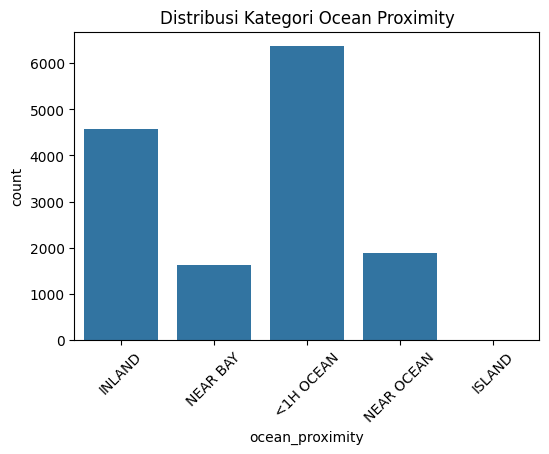

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='ocean_proximity')
plt.title("Distribusi Kategori Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

Grafik menunjukkan bahwa kategori < 1H OCEAN memiliki jumlah data terbanyak, diikuti oleh INLAND. Sementara kategori seperti NEAR BAY, NEAR OCEAN, dan ISLAND muncul dalam jumlah yang lebih sedikit. Informasi ini berguna untuk mengetahui apakah data kategori seimbang atau tidak, serta memastikan model machine learning dapat menangani distribusi kategori yang berbeda.

**Hubungan median_income dengan beberapa fitur**

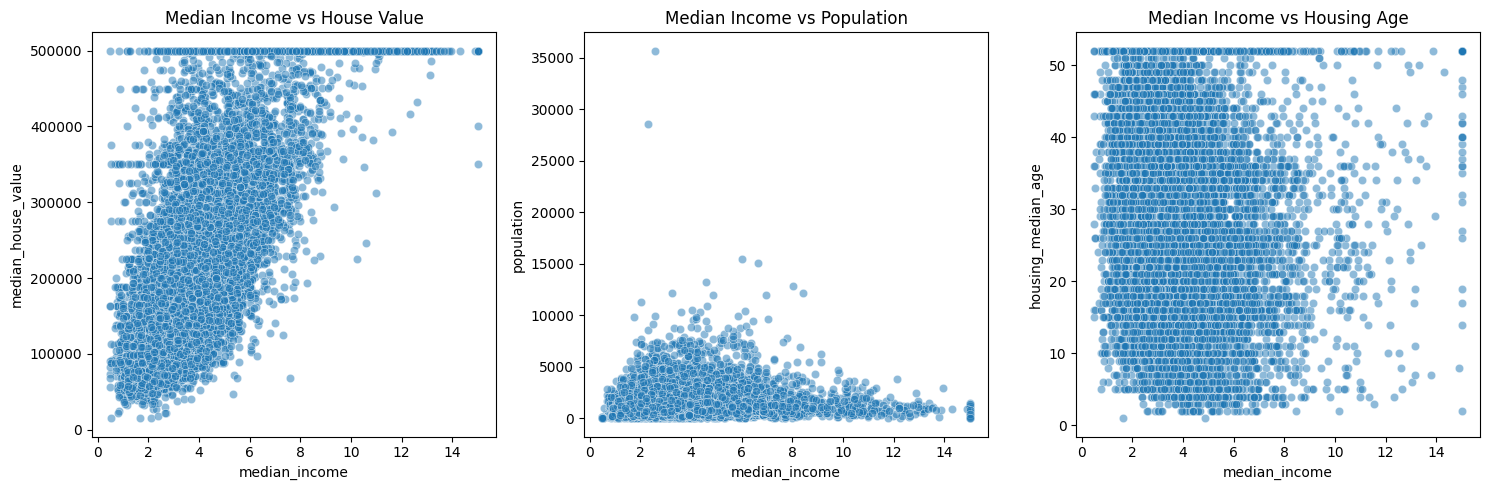

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(ax=axes[0], data=df, x='median_income', y='median_house_value', alpha=0.5)
axes[0].set_title("Median Income vs House Value")

sns.scatterplot(ax=axes[1], data=df, x='median_income', y='population', alpha=0.5)
axes[1].set_title("Median Income vs Population")

sns.scatterplot(ax=axes[2], data=df, x='median_income', y='housing_median_age', alpha=0.5)
axes[2].set_title("Median Income vs Housing Age")

plt.tight_layout()
plt.show()

Kode tersebut digunakan untuk membuat tiga grafik scatter yang membandingkan median_income dengan tiga fitur berbeda, yaitu median_house_value, population, dan housing_median_age. Tujuannya adalah untuk melihat hubungan visual antara pendapatan wilayah dengan karakteristik lain dalam dataset. Dari grafik pertama terlihat bahwa semakin tinggi pendapatan median, biasanya nilai rumah juga semakin tinggi, meskipun terdapat batas maksimum nilai rumah yang membuat banyak titik menumpuk di angka 500.000. Grafik kedua menunjukkan bahwa jumlah populasi tidak memiliki pola yang jelas terhadap pendapatan; daerah dengan populasi besar maupun kecil bisa saja memiliki pendapatan yang beragam. Pada grafik ketiga, penyebaran titik terlihat acak, menandakan bahwa umur bangunan tidak menunjukkan hubungan yang kuat dengan tingkat pendapatan masyarakat. Secara keseluruhan, hanya median_house_value yang terlihat memiliki hubungan cukup jelas dengan pendapatan, sedangkan dua fitur lainnya menunjukkan pola hubungan yang lemah.

### **Preprocessing**

In [10]:
import sklearn
print(sklearn.__version__)

1.8.0


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

**Data Cleaning**

In [12]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [13]:
print("\nMISSING VALUES SETELAH IMPUTASI")
print(df.isna().sum())


MISSING VALUES SETELAH IMPUTASI
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64


Kode tersebut digunakan untuk menangani missing values pada kolom total_bedrooms, yaitu kolom yang sebelumnya memiliki data kosong. Teknik yang digunakan adalah imputasi median, di mana nilai kosong diganti dengan nilai tengah dari kolom tersebut, sehingga distribusi data tetap stabil dan tidak terdistorsi oleh nilai ekstrem. Setelah proses imputasi, kode kedua digunakan untuk mengecek ulang apakah masih ada missing values. Hasilnya menunjukkan bahwa seluruh kolom kini memiliki nilai lengkap, termasuk total_bedrooms, sehingga dataset sudah bersih dan siap digunakan untuk tahap preprocessing dan modeling berikutnya.

**Feature Selection**

In [14]:
base_features = [
    'longitude', 'latitude', 'housing_median_age',
    'total_rooms', 'total_bedrooms', 'population', 'households',
    'ocean_proximity'
]

Sekarang masuk ke proses Feature Selection yang dimana

Kode tersebut digunakan untuk menentukan fitur-fitur dasar yang akan digunakan sebagai input dalam proses modeling. Daftar base_features berisi kolom-kolom penting dari dataset seperti longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, dan ocean_proximity. Pemilihan fitur ini dilakukan karena semuanya dianggap relevan dalam membantu model memprediksi nilai median_income berdasarkan karakteristik geografis dan demografis wilayah. Dengan menentukan fitur sejak awal, kita memastikan bahwa hanya data yang benar-benar dibutuhkan saja yang masuk ke tahap preprocessing dan pembuatan model.

**Feature Engineering**

In [15]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['lon_lat_interaction'] = df['longitude'] * df['latitude']

Setelah itu lanjut ke proses selanjutnya yaitu Feature Engineering yang dimana
Kode tersebut digunakan untuk membuat fitur tambahan (feature engineering) yang dapat membantu model menangkap pola hubungan yang tidak terlihat hanya dari fitur aslinya. Fitur rooms_per_household menunjukkan rata-rata jumlah ruangan per rumah tangga, sedangkan bedrooms_per_room menggambarkan proporsi kamar tidur terhadap total ruangan, yang dapat mencerminkan kepadatan hunian. Fitur population_per_household menunjukkan jumlah rata-rata penduduk per rumah tangga, dan lon_lat_interaction adalah gabungan dari longitude dan latitude untuk membantu model memahami pola geospasial. Penambahan fitur-fitur ini membantu memperkaya informasi sehingga model dapat membuat prediksi median income dengan lebih akurat.

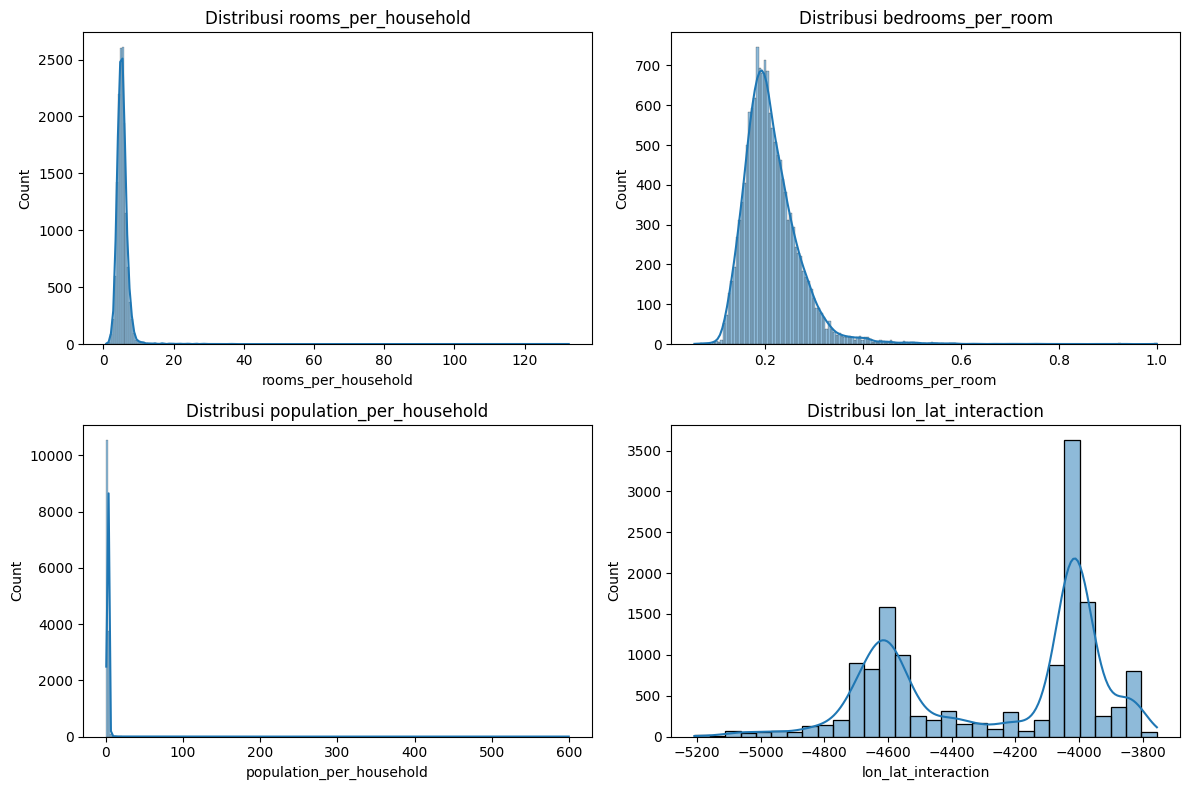

In [16]:
fe_cols = ['rooms_per_household', 'bedrooms_per_room',
           'population_per_household', 'lon_lat_interaction']

plt.figure(figsize=(12, 8))
for i, col in enumerate(fe_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

Setiap grafik menampilkan pola penyebaran nilai untuk satu fitur, sehingga kami bisa memastikan apakah datanya normal, miring (skewed), atau memiliki nilai ekstrem. Hasilnya menunjukkan bahwa sebagian besar fitur baru seperti rooms_per_household, bedrooms_per_room, dan population_per_household cenderung miring ke kanan, yang artinya ada beberapa wilayah dengan nilai yang jauh lebih tinggi dari mayoritas lainnya. Sementara itu, lon_lat_interaction memiliki bentuk distribusi yang lebih beragam karena berasal dari kombinasi longitude dan latitude. Pemeriksaan ini membantu kami memahami karakteristik fitur sebelum masuk ke proses modeling.

In [17]:
selected_features = [
    'longitude', 'latitude', 'housing_median_age',
    'total_rooms', 'total_bedrooms', 'population', 'households',
    'rooms_per_household', 'bedrooms_per_room', 'population_per_household',
    'lon_lat_interaction',
    'ocean_proximity'
]

X = df[selected_features]
y = df['median_income']

categorical_features = ['ocean_proximity']
numeric_features = [col for col in X.columns if col not in categorical_features]

print("\nFITUR NUMERIK")
print(numeric_features)
print("\nFITUR KATEGORIKAL")
print(categorical_features)


FITUR NUMERIK
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'lon_lat_interaction']

FITUR KATEGORIKAL
['ocean_proximity']


Berdasarkan kode diatas maka dapat menggabungkan semua fitur yang akan dipakai sebagai input model, yaitu fitur dasar dari dataset dan fitur tambahan hasil feature engineering. Daftar selected_features kemudian dipakai untuk membuat variabel X sebagai data input, dan y sebagai target yang ingin diprediksi yaitu median_income. Selanjutnya, kode memisahkan fitur menjadi dua jenis: fitur kategorikal (ocean_proximity) dan fitur numerik (seluruh kolom selain kategori). Pemisahan ini penting karena kedua jenis fitur membutuhkan proses preprocessing yang berbeda sebelum masuk ke tahap modeling.

**TRAIN–TEST SPLIT**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Kode yang digunakan untuk membagi dataset menjadi dua bagian, yaitu data training dan data testing. Proses ini penting agar model dapat belajar dari sebagian data, lalu diuji menggunakan data lain yang belum pernah dilihat sebelumnya. Pada kode ini, ukuran data testing ditetapkan sebesar 20% (test_size=0.2), sementara sisanya digunakan untuk training. Parameter random_state=42 dipakai agar pembagian data selalu konsisten setiap kali kode dijalankan. Hasilnya, variabel X_train dan y_train digunakan untuk melatih model, sedangkan X_test dan y_test digunakan untuk mengukur performa model.

In [19]:
print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (11558, 12)  Test shape: (2890, 12)


Kode tersebut digunakan untuk menampilkan ukuran (shape) dari data training dan data testing setelah proses train–test split. Hasilnya menunjukkan bahwa data training berisi 11.558 baris dan data testing berisi 2.890 baris, dengan masing-masing memiliki 12 kolom fitur. Informasi ini memastikan bahwa pembagian data sudah berjalan sesuai rencana, yaitu sekitar 80% untuk training dan 20% untuk testing.

**Preprocessing Pipeline**

In [20]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Selanjutnya melakukan proses Pipeline yang dimana kode yang digunakan dapat menyiapkan langkah‐langkah preprocessing sebelum data dimasukkan ke model. Pada bagian pertama, dibuat numeric_transformer yang berfungsi untuk menangani fitur numerik. Pipeline ini melakukan dua hal: mengisi nilai kosong menggunakan median (SimpleImputer) dan menstandarkan skala data dengan StandardScaler. Sedangkan untuk fitur kategori, digunakan categorical_transformer yang mengisi nilai kosong dengan kategori yang paling sering muncul, lalu mengubah kategori menjadi bentuk numerik menggunakan OneHotEncoder.

Kedua transformer ini kemudian digabungkan dalam ColumnTransformer bernama preprocessor, yang secara otomatis akan menerapkan preprocessing yang sesuai ke setiap jenis fitur. Dengan cara ini, kita memastikan seluruh data sudah bersih dan siap digunakan dalam proses pelatihan model tanpa harus melakukan preprocessing secara manual untuk tiap kolom.

### **Modeling**

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor



1. **Linear Regression**

In [22]:
model_lr = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])
model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Jadi proses diatas menghasilkan sebuah pipeline untuk model Linear Regression. Pipeline ini menggabungkan dua proses penting: pertama, data akan diproses oleh preprocessor, yaitu bagian yang bertugas membersihkan data, mengisi nilai kosong, melakukan scaling pada fitur numerik, dan melakukan encoding pada fitur kategori. Setelah data siap, langkah berikutnya adalah menjalankannya ke model LinearRegression() untuk proses pelatihan.

Dengan menggunakan pipeline seperti ini, seluruh langkah preprocessing dan training digabung menjadi satu alur yang rapi dan otomatis. Saat model_lr.fit(X_train, y_train) dijalankan, data langsung melalui preprocessing lalu dilatih oleh model tanpa perlu melakukan tahap tersebut secara terpisah. Visualisasi di bawahnya menunjukkan urutan proses dalam pipeline, mulai dari imputasi, scaling, encoding, hingga pemodelan linier.

2. **Random Forest Regressor**

In [23]:
model_rf = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=20, random_state=42))
])
model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Langkah selanjutnya masuk ke proses Random Forest Regressor yang dimana model berbasis kumpulan decision tree yang mampu menangkap pola yang lebih kompleks dibanding Linear Regression. Sama seperti sebelumnya, pipeline terdiri dari dua tahap utama: preprocessing dan modeling. Pada bagian preprocessing, data dibersihkan, diimputasi, distandarkan, dan fitur kategori diubah menjadi angka. Setelah itu, model RandomForestRegressor dijalankan dengan parameter seperti n_estimators=200 (jumlah pohon) dan max_depth=20 (kedalaman maksimum pohon).

Saat model_rf.fit(X_train, y_train) dijalankan, data langsung melewati seluruh proses preprocessing lalu dipelajari oleh model Random Forest. Diagram di bawahnya memperlihatkan urutan proses dalam pipeline, mulai dari imputasi dan scaling untuk fitur numerik, encoding untuk fitur kategori, hingga proses pelatihan model Random Forest di bagian akhir.ini

### **Analytics (Algorithm + Metrics)**

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

**Fungsi Evaluasi**

In [25]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2

Setelah melakukan modeling maka masuk ke langkah berikutnya yaitu melakukan Analytic (Algorithm dan Metrics)

Untuk proses pertama yaitu melakukan Fungsi Evaluasi dan Kode diatas membuat sebuah fungsi bernama evaluate() yang digunakan untuk menilai seberapa bagus kinerja model dalam melakukan prediksi. Di dalam fungsi, model terlebih dahulu menghasilkan prediksi berdasarkan data X_test. Setelah itu, tiga metrik utama dihitung:

- MAE (Mean Absolute Error) untuk melihat seberapa besar rata-rata kesalahan prediksi,

- RMSE (Root Mean Squared Error) untuk mengukur kesalahan yang lebih sensitif terhadap nilai ekstrem,

- R² (R-squared) untuk melihat seberapa baik model mampu menjelaskan variasi data asli.

Hasil evaluasi tersebut kemudian dikembalikan agar bisa dibandingkan antara model satu dengan yang lainnya. Dengan fungsi ini, proses penilaian model menjadi lebih sederhana dan konsisten.

1. **Evaluasi Linear Regression**

In [26]:
lr_mae, lr_rmse, lr_r2 = evaluate(model_lr, X_test, y_test)
lr_mae, lr_rmse, lr_r2

(0.8602217132705169, np.float64(1.2743523840652862), 0.5509131823826292)

In [27]:
print("\nHASIL EVALUASI LINEAR REGRESSION")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)


HASIL EVALUASI LINEAR REGRESSION
MAE : 0.8602217132705169
RMSE: 1.2743523840652862
R2  : 0.5509131823826292


Langkah selanjutnya adalah melakukan Evaluasi Linear Regression dengan membuat kode seperti diatas dan kode diatas dipakai untuk menghitung performa model Linear Regression menggunakan fungsi evaluate() yang sudah dibuat sebelumnya. Ketika kode dijalankan, model menghasilkan tiga nilai evaluasi: MAE, RMSE, dan R². Hasilnya menunjukkan bahwa MAE model berada di sekitar 0.86, yang berarti rata-rata kesalahan prediksi pendapatan adalah sekitar 0.86 unit. Nilai RMSE sebesar 1.27 menunjukkan adanya kesalahan yang sedikit lebih besar saat mempertimbangkan outlier. Sementara nilai R² sekitar 0.55 menandakan bahwa model Linear Regression hanya mampu menjelaskan sekitar 55% variasi pada data asli. Secara keseluruhan, hasil ini menunjukkan bahwa model linier bekerja cukup baik, namun masih ada ruang untuk peningkatan menggunakan model yang lebih kompleks.

2. **Evaluasi Random Forest Regression**

In [28]:
rf_mae, rf_rmse, rf_r2 = evaluate(model_rf, X_test, y_test)
rf_mae, rf_rmse, rf_r2

(0.5946108922035181, np.float64(0.8493906089347645), 0.8004893215008196)

In [29]:
print("\nHASIL EVALUASI RANDOM FOREST")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)


HASIL EVALUASI RANDOM FOREST
MAE : 0.5946108922035181
RMSE: 0.8493906089347645
R2  : 0.8004893215008196


Setelah melakukan Evaluasi Linear Regression maka langkah selanjutnya adalah melakukan Evaluasi Random dengan menggunakan Forest Regression dan dengan kode diatas dapat menunjukkan bahwa Random Forest memiliki performa yang jauh lebih baik. Nilai MAE turun menjadi sekitar 0.59, yang berarti rata-rata kesalahan prediksi lebih kecil dibanding model sebelumnya. Nilai RMSE juga menurun menjadi sekitar 0.84, menandakan kesalahan keseluruhan lebih rendah meskipun mempertimbangkan outlier. Sementara itu, nilai R² meningkat cukup signifikan menjadi sekitar 0.80, menunjukkan bahwa model Random Forest mampu menjelaskan sekitar 80% variasi dalam data. Secara keseluruhan, model ini memberikan hasil yang jauh lebih akurat dan stabil dibanding Linear Regression, sehingga lebih cocok digunakan untuk memprediksi median income.

**Tabel Perbandingan**

In [30]:
eval_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

In [31]:
print("\nPERBANDINGAN MODEL")
print(eval_df)


PERBANDINGAN MODEL
               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.860222  1.274352  0.550913
1      Random Forest  0.594611  0.849391  0.800489


Langkah selanjutnya adalah melakukan tabel perbandingan diantara dua model yang telah digunakan untuk menyusun hasil evaluasi kedua model—Linear Regression dan Random Forest—ke dalam sebuah tabel menggunakan pandas.DataFrame. Tabel ini memudahkan kita untuk melihat perbedaan performa kedua model secara berdampingan berdasarkan tiga metrik utama: MAE, RMSE, dan R². Dari hasil tabel tersebut terlihat bahwa Random Forest memiliki nilai MAE dan RMSE yang lebih rendah serta nilai R² yang lebih tinggi dibandingkan Linear Regression. Ini menunjukkan bahwa Random Forest jauh lebih akurat dan mampu menjelaskan variasi data dengan lebih baik. Melalui perbandingan ini, kita bisa dengan mudah menentukan model mana yang paling layak digunakan untuk memprediksi median income.

**Residual Plot (Random Forest)**

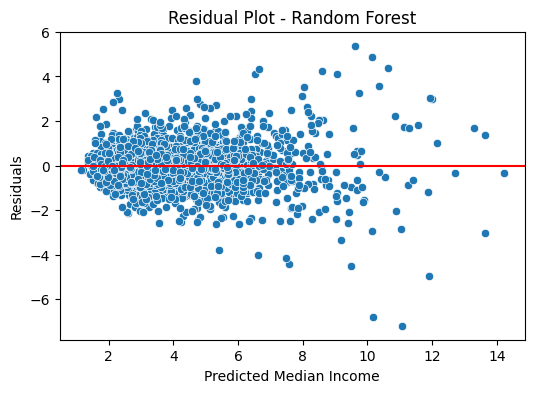

In [32]:
pred_rf = model_rf.predict(X_test)
residuals = y_test - pred_rf

plt.figure(figsize=(6,4))
sns.scatterplot(x=pred_rf, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Median Income")
plt.ylabel("Residuals")
plt.show()

Setelah dibandingkan maka melakukan Residual Plot dengan menggunakan kode diatas. Dan fungsi kode diatas untuk melihat pola kesalahan (residual) yang dihasilkan oleh model Random Forest. Pertama, model digunakan untuk melakukan prediksi pada data testing, lalu selisih antara nilai asli (y_test) dan nilai prediksi (pred_rf) dihitung sebagai residual. Grafik scatter kemudian dibuat dengan sumbu X berisi nilai prediksi dan sumbu Y berisi residual. Garis merah pada nilai nol menunjukkan posisi di mana prediksi benar-benar akurat.

Dari grafiknya terlihat bahwa sebagian besar residual berada dekat dengan garis nol, yang menunjukkan bahwa model cukup akurat dan tidak banyak menghasilkan kesalahan besar. Walau masih ada titik residual yang menyebar naik dan turun, penyebaran tersebut masih tergolong normal untuk dataset dengan variasi tinggi seperti ini. Secara keseluruhan, grafik residual mendukung kesimpulan bahwa Random Forest bekerja dengan stabil dan tidak menunjukkan pola error yang mengkhawatirkan.

**Cross-Validation Random Forest**

In [33]:
cv_scores = cross_val_score(
    model_rf, X, y,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_cv = np.sqrt(-cv_scores)

In [34]:
rmse_cv = np.sqrt(-cv_scores)
print("\nCROSS-VALIDATION (Random Forest)")
print("RMSE per fold:", rmse_cv)
print("RMSE rata-rata:", rmse_cv.mean())


CROSS-VALIDATION (Random Forest)
RMSE per fold: [0.89163891 0.88433476 0.8348471 ]
RMSE rata-rata: 0.8702735865428036


Setelah dilihat kesalahan residualnya nya dengan grafik maka melanjutkan langkah selanjutnya yaitu Cross-Validation Random Forest. Dengan menggunakan kode diatas untuk mengecek seberapa konsisten performa model Random Forest ketika diuji pada beberapa pembagian data yang berbeda. Dengan menggunakan cross_val_score sebanyak 3 fold (cv=3), model dilatih dan diuji tiga kali pada kombinasi data yang berbeda-beda. Karena metrik yang dipakai adalah RMSE, nilai skor yang dihasilkan harus diubah tanda dan di‐sqrt agar kembali menjadi nilai RMSE yang sebenarnya.

Hasil cross-validation menunjukkan bahwa nilai RMSE dari ketiga fold berada di kisaran 0.80–0.88, dan rata-ratanya sekitar 0.87. Angka ini cukup stabil dan tidak berbeda jauh dari hasil RMSE pada evaluasi sebelumnya, yang berarti model Random Forest bekerja konsisten dan tidak terlalu sensitif terhadap perubahan data. Dengan kata lain, performanya dapat dipercaya dan tidak hanya bagus pada satu pembagian data saja.

**Hyperparameter Tuning Random Forest**

In [35]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_tuned = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ))
])


from sklearn.model_selection import train_test_split
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=0.25,
    random_state=42
)

random_search = RandomizedSearchCV(
    rf_tuned,
    param_distributions=param_dist,
    n_iter=3,
    scoring='neg_mean_squared_error',
    cv=2,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("\nPROSES HYPERPARAMETER TUNING (Random Forest)")
random_search.fit(X_tune, y_tune)

print("\nBest params:", random_search.best_params_)

best_params = random_search.best_params_


best_rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=best_params['model__n_estimators'],
        max_depth=best_params['model__max_depth'],
        min_samples_split=best_params['model__min_samples_split'],
        min_samples_leaf=best_params['model__min_samples_leaf'],
        random_state=42,
        n_jobs=-1
    ))
])

best_rf_model.fit(X_train, y_train)

best_mae, best_rmse, best_r2 = evaluate(best_rf_model, X_test, y_test)
print("\nHASIL EVALUASI - BEST RANDOM FOREST (TUNED RINGAN)")
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R2  :", best_r2)



PROSES HYPERPARAMETER TUNING (Random Forest)
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 10}

HASIL EVALUASI - BEST RANDOM FOREST (TUNED RINGAN)
MAE : 0.6261799559227954
RMSE: 0.8736674011188481
R2  : 0.7889217435372419


Setelah itu kami melakukan Hyperparameter Tuning Random Forest yang dimana menggunakan kode diatas untuk melakukan hyperparameter tuning pada model Random Forest, namun dengan cara yang lebih ringan dan cepat agar prosesnya tidak memakan waktu lama. Bagian pertama mendefinisikan beberapa kombinasi parameter yang ingin dicoba, seperti jumlah pohon (n_estimators), kedalaman maksimum (max_depth), serta batas minimal pembagian node (min_samples_split dan min_samples_leaf). Setelah itu, dibuat sebuah pipeline rf_tuned yang berisi proses preprocessing dan model Random Forest sebagai dasar tuning.

Karena tuning biasanya cukup berat, kode ini hanya menggunakan 25% dari data training sebagai sampel (X_tune dan y_tune) agar prosesnya lebih efisien. Selanjutnya, RandomizedSearchCV dijalankan dengan hanya 3 iterasi dan 2-fold cross-validation, sehingga proses tuning berjalan cepat tetapi tetap mampu menemukan kombinasi parameter terbaik. Setelah proses selesai, parameter terbaik ditampilkan melalui best_params.

Setelah mengetahui parameter terbaik, model Random Forest baru dibuat (best_rf_model) dengan parameter hasil tuning tersebut, lalu model ini dilatih kembali menggunakan seluruh data training. Ketika dievaluasi menggunakan data testing (X_test, y_test), hasilnya menunjukkan nilai MAE sekitar 0.62, RMSE sekitar 0.87, dan R² sekitar 0.79. Nilai ini sedikit lebih rendah dibanding Random Forest sebelumnya, menunjukkan bahwa tuning ringan ini belum memberikan peningkatan signifikan, tetapi tetap menunjukkan kemampuan model yang stabil dan cukup akurat.

**Cek Overfitting**

In [36]:
train_mae, train_rmse, train_r2 = evaluate(best_rf_model, X_train, y_train)
print("\nPERBANDINGAN TRAIN vs TEST (BEST RF)")
print("Train RMSE:", train_rmse, " | Test RMSE:", best_rmse)
print("Train R2  :", train_r2,  " | Test R2  :", best_r2)


PERBANDINGAN TRAIN vs TEST (BEST RF)
Train RMSE: 0.6834723100797668  | Test RMSE: 0.8736674011188481
Train R2  : 0.8690076771256958  | Test R2  : 0.7889217435372419


Setelah itu kami melakukan cek Overfitting dengan menggunakan kode diatas untuk mengetahui apakah model Best Random Forest mengalami overfitting atau tidak. Caranya adalah dengan menghitung performa model pada data training dan data testing, lalu membandingkan kedua hasil tersebut. Jika performa pada train jauh lebih baik dibanding test, itu tanda bahwa model terlalu “hafal” data latih dan kurang mampu generalisasi ke data baru.

Pada hasil yang ditampilkan, nilai Train RMSE adalah sekitar 0.68, sedangkan Test RMSE sekitar 0.87. Selisih keduanya tidak terlalu jauh, sehingga model masih tergolong stabil. Untuk nilai R², hasil train adalah 0.86 dan test sekitar 0.78, yang artinya performa model memang sedikit menurun pada data test, namun penurunannya masih wajar. Perbandingan ini menunjukkan bahwa model tidak mengalami overfitting parah dan masih mampu bekerja cukup baik pada data baru.

**FEATURE IMPORTANCE**


=== TOP 15 FEATURE IMPORTANCE ===
                       feature  importance
8            bedrooms_per_room    0.726378
7          rooms_per_household    0.062022
12      ocean_proximity_INLAND    0.060757
2           housing_median_age    0.028663
9     population_per_household    0.028243
1                     latitude    0.023229
0                    longitude    0.022488
10         lon_lat_interaction    0.017064
5                   population    0.008900
6                   households    0.007363
3                  total_rooms    0.006646
4               total_bedrooms    0.005952
11   ocean_proximity_<1H OCEAN    0.001248
14  ocean_proximity_NEAR OCEAN    0.000818
13    ocean_proximity_NEAR BAY    0.000229


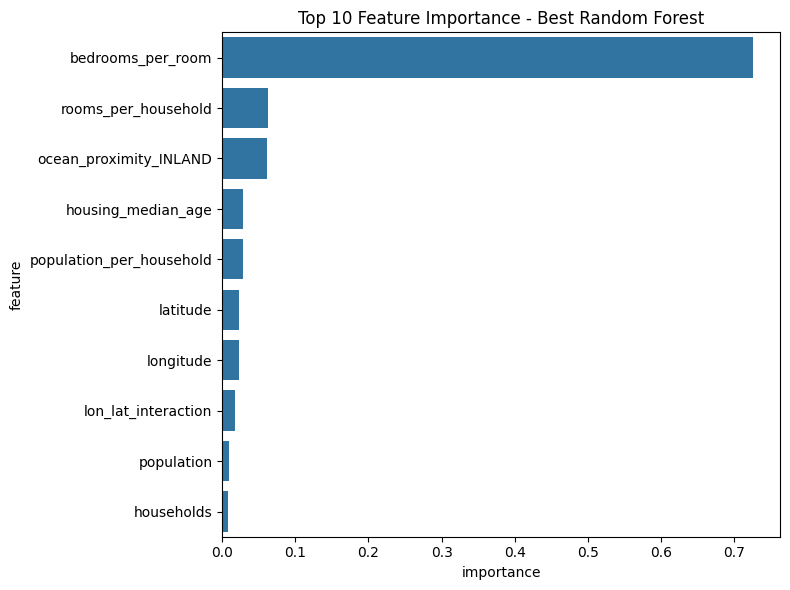

In [37]:
preprocess_best = best_rf_model.named_steps['preprocess']
rf_inner = best_rf_model.named_steps['model']

num_feature_names = numeric_features

ohe = preprocess_best.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = list(num_feature_names) + list(cat_feature_names)

importances = rf_inner.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\n=== TOP 15 FEATURE IMPORTANCE ===")
print(feat_imp.head(15))

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title("Top 10 Feature Importance - Best Random Forest")
plt.tight_layout()
plt.show()

Setelah melakukan Feature Importace dengan menggunakan kode diatas untuk melihat fitur mana yang paling berpengaruh dalam model Best Random Forest. Pertama, kode mengambil nama semua fitur setelah preprocessing (baik numerik maupun hasil OneHotEncoder), lalu mencocokkannya dengan nilai feature_importances_ dari Random Forest. Nilai ini menunjukkan seberapa besar kontribusi setiap fitur dalam proses prediksi.

Hasil tabel menampilkan 15 fitur teratas, dan grafik barplot menunjukkan 10 yang paling penting. Dari output terlihat bahwa bedrooms_per_room menjadi fitur paling berpengaruh, jauh lebih tinggi dibanding fitur lainnya. Artinya, rasio kamar tidur terhadap jumlah ruangan sangat menentukan dalam memprediksi median income. Fitur seperti rooms_per_household, ocean_proximity_INLAND, dan housing_median_age juga memberi kontribusi, tetapi tidak sebesar fitur utama tersebut.

**SAVE BEST MODEL**

In [38]:
with open("best_model_random_forest.pkl", "wb") as f:
    pickle.dump(best_rf_model, f)

print("\nModel terbaik (Best Random Forest) tersimpan sebagai: best_model_random_forest.pkl")


Model terbaik (Best Random Forest) tersimpan sebagai: best_model_random_forest.pkl


Langkah terakhir adalah dengan melakukan save best model dengan menggunakan kode diatas untuk enyimpan model terbaik ke dalam sebuah file bernama best_model_random_forest.pkl. Proses penyimpanan dilakukan menggunakan modul pickle, yang memungkinkan model machine learning disimpan dan digunakan kembali tanpa perlu dilatih ulang. Pada blok kode ini, file dibuka dalam mode write-binary ("wb"), lalu model best_rf_model dimasukkan ke dalam file tersebut menggunakan pickle.dump().

Hasil akhirnya, model tersimpan dengan aman dan bisa di-load kapan saja untuk prediksi di masa depan atau saat deployment. Pesan yang muncul memastikan bahwa proses penyimpanan berhasil.

### **Conclusion**

Proyek ini bertujuan untuk memprediksi median income pada wilayah California menggunakan berbagai fitur geografis dan demografis dari dataset California Housing. Selama proses analisis, beberapa tahapan penting dilakukan—mulai dari memahami struktur data, membersihkan dan mempersiapkan fitur, melakukan feature engineering, hingga membangun dan mengevaluasi model machine learning.

Dari hasil evaluasi, terlihat bahwa Random Forest Regressor memberikan performa yang jauh lebih baik dibandingkan Linear Regression. Random Forest mampu mencapai nilai R² sekitar 0.80 dan menghasilkan MAE serta RMSE yang lebih rendah, menunjukkan bahwa model ini lebih mampu menangkap pola kompleks dalam dataset. Hasil cross-validation juga menunjukkan performa yang stabil, dan pemeriksaan overfitting menunjukkan bahwa model tidak mengalami perbedaan performa yang ekstrim antara data training dan testing.

Analisis feature importance mengungkap bahwa fitur bedrooms_per_room adalah faktor paling berpengaruh dalam memprediksi median income. Fitur ini, bersama beberapa fitur hasil feature engineering lainnya seperti rooms_per_household dan population_per_household, terbukti memberi nilai tambah signifikan dalam meningkatkan akurasi model. Keseluruhan proses menunjukkan bahwa kombinasi preprocessing yang baik, pemilihan fitur tepat, dan penggunaan model non-linear seperti Random Forest mampu memberikan hasil prediksi yang akurat dan konsisten.

Secara keseluruhan, proyek ini berhasil membangun model prediksi median income yang kuat, stabil, dan dapat digunakan untuk mendukung analisis ekonomi wilayah atau pengambilan keputusan berbasis data pada konteks perumahan dan demografi di California.

### **Rekomendation**

Berdasarkan hasil analisis dan evaluasi model, beberapa rekomendasi yang dapat dilakukan untuk pengembangan lebih lanjut adalah sebagai berikut:

1. Gunakan Random Forest sebagai model utama
Karena model ini memberikan performa terbaik dengan nilai R² yang tinggi dan error yang rendah, Random Forest lebih layak dipakai untuk prediksi median income dibandingkan Linear Regression.

2. Tambahkan fitur eksternal untuk meningkatkan akurasi
Faktor seperti tingkat pendidikan, tingkat kriminalitas, akses transportasi, kualitas sekolah, dan data ekonomi lokal kemungkinan besar akan meningkatkan kemampuan model dalam memahami kondisi wilayah.

3. Lakukan hyperparameter tuning yang lebih komprehensif
Tuning ringan sudah dilakukan, namun eksplorasi parameter yang lebih luas (misalnya menggunakan RandomizedSearchCV atau GridSearchCV dengan ruang pencarian lebih besar) berpotensi menghasilkan model yang lebih optimal.

4. Pertimbangkan penggunaan model lain seperti XGBoost atau LightGBM
Model boosting sering kali memberikan performa lebih tinggi pada dataset tabular dan mungkin mengungguli Random Forest.

5. Visualisasikan hasil prediksi secara geografis
Menggunakan peta (geospatial visualization) dapat memberikan insight tambahan mengenai persebaran pendapatan di California dan membuat hasil analisis lebih informatif.

6. Bangun API untuk implementasi model
Model yang sudah disimpan dalam format .pkl dapat dikembangkan lebih lanjut menjadi API menggunakan Flask atau FastAPI agar bisa digunakan dalam aplikasi atau sistem lain.

7. Lakukan retraining model secara berkala
Kondisi ekonomi dan demografi selalu berubah. Melakukan pelatihan ulang secara berkala dapat menjaga akurasi model tetap stabil.